In [149]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import Sampler, QiskitRuntimeService
from math import pi

# Excercise 1

Here we have a 5-qubit QFT:

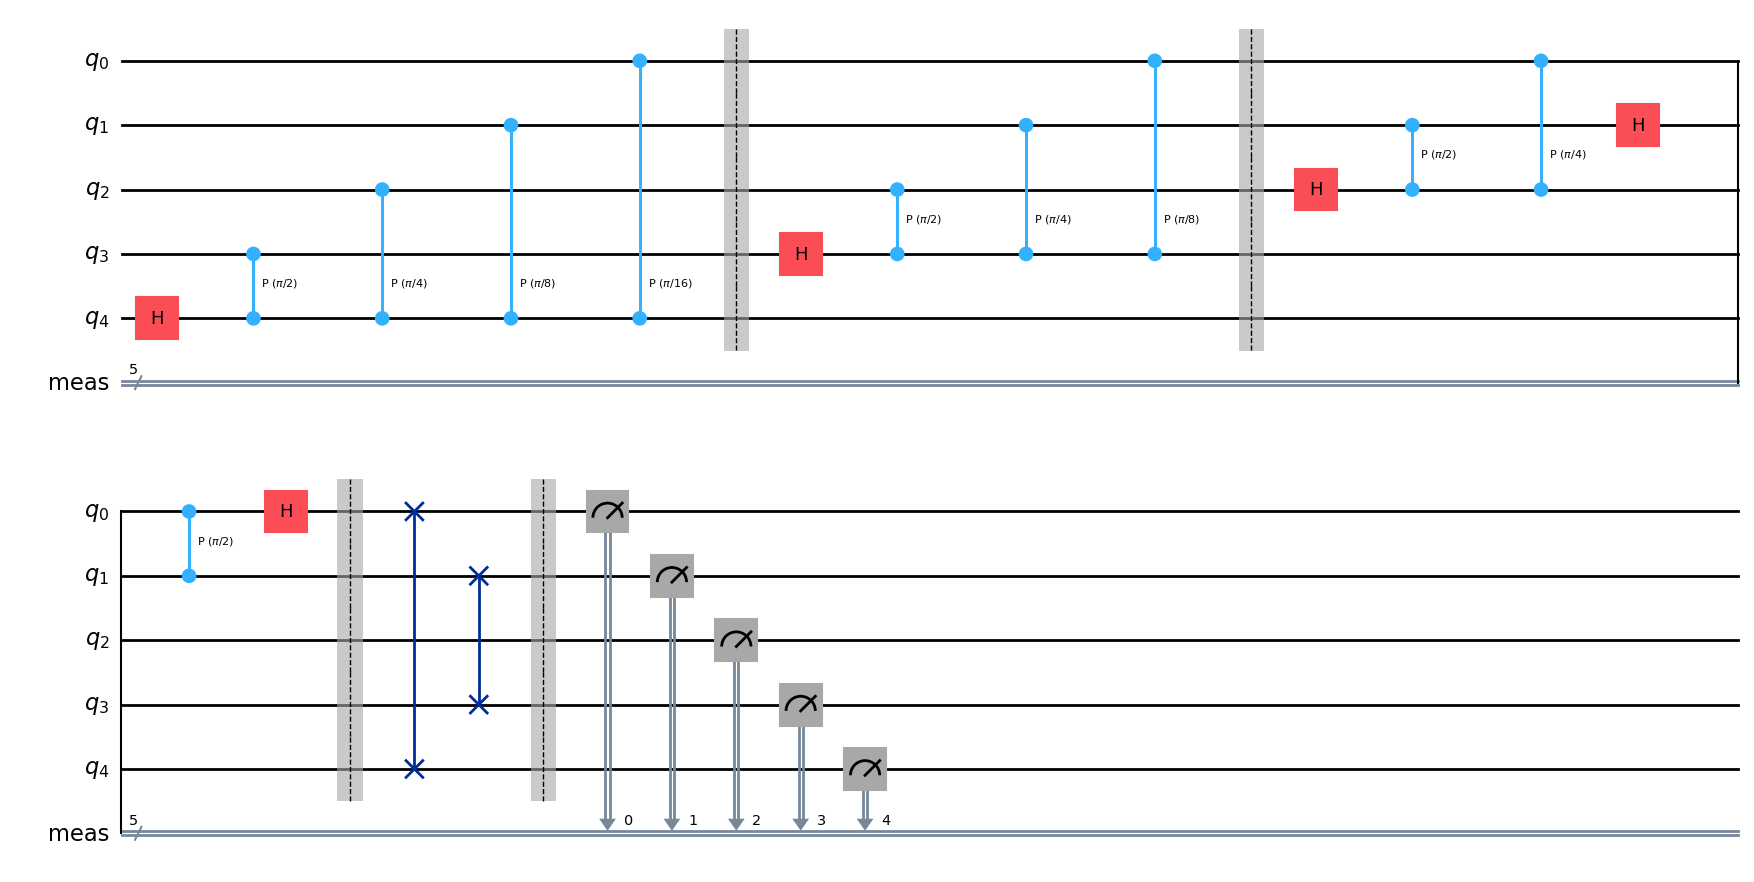

In [150]:
QFT = QuantumCircuit(5)


QFT.h(4)
QFT.cp(pi/2, 3, 4) 
QFT.cp(pi/4, 2, 4) 
QFT.cp(pi/8, 1, 4)
QFT.cp(pi/16, 0, 4) 
QFT.barrier()

QFT.h(3)
QFT.cp(pi/2, 2, 3)
QFT.cp(pi/4, 1, 3) 
QFT.cp(pi/8, 0, 3)
QFT.barrier()

QFT.h(2)
QFT.cp(pi/2, 1, 2) 
QFT.cp(pi/4, 0, 2) 

QFT.h(1)
QFT.cp(pi/2, 0, 1) 
QFT.h(0)
QFT.barrier()

QFT.swap(0,4)
QFT.swap(1,3)

QFT.measure_all()

QFT.draw("mpl")

# Excercise 2

Here we have a 5-qubit Deutsche-Jozsa algorithm given the truth table presented on the excercise statement. Notice that f takes to 1 all the qubits such that their figures sum (mod2) equals 1 and f takes to 0 the qubits such that their figures sum (mod2) equals 0. That leads to the Oracle presented below were we apply CNOTs in all the three qubits without flipping any of them. The logic of the truth table is equivalent to the function f(x_1,x_2,x_3) = x_1 + x_2 + x_3 (mod2).

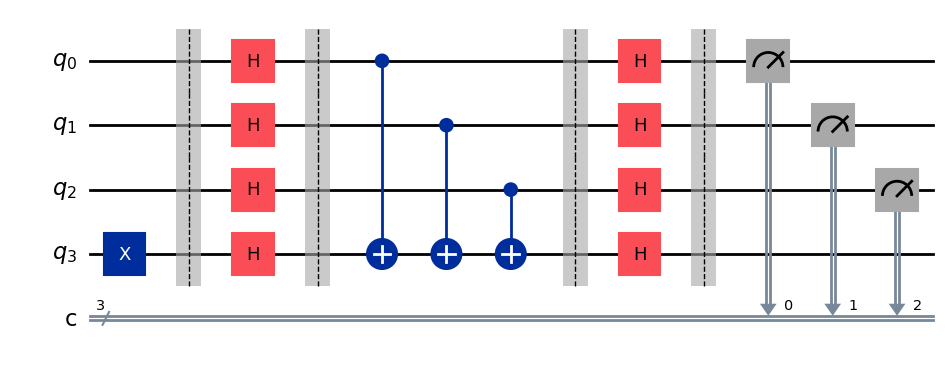

In [151]:
n = 3
DJ_circuit = QuantumCircuit(n+1,n)

DJ_circuit.x(3)
DJ_circuit.barrier()

DJ_circuit.h(range(n+1))
DJ_circuit.barrier()

# Controlled-NOT gates
for qubit in range(n):
    DJ_circuit.cx(qubit, n)

DJ_circuit.barrier()
DJ_circuit.h(range(n+1))
DJ_circuit.barrier()

DJ_circuit.measure([0,1,2], [0,1,2])
DJ_circuit.draw("mpl")

# Exercise 3

Let's run both algorithms with the QASM simulator, which is not affected by any type o noise.

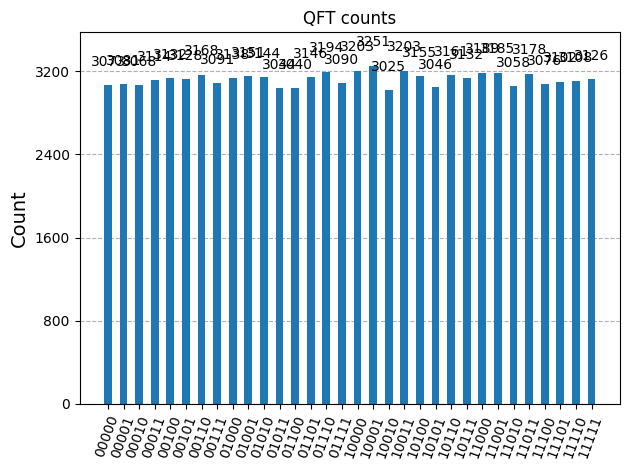

In [268]:
simulator = Aer.get_backend('qasm_simulator')

# Transpile
QFT_transpiled = transpile(QFT, simulator)

# Execute and results
job = simulator.run(QFT_transpiled, shots=100000, memory=True)
result = job.result()
counts_QFT_sim = result.get_counts()
plot_histogram(counts_QFT_sim, title='QFT counts')

The QFT performs as expected, returning an almost perfect even distribution over the computational basis. Let's calculate the error due to randomness, an argument we are going to use again when calculating noise in the quantum computer. To calculate the error rate of this circuit we need to calculate how much the values of each of the outputs have differed from their expected value which is a proportion of 1/32 over the total number of shots, in this specific case, we are running 100.000 shots so 100.000/32. Next we have to divide by 2, otherwise we would be counting the error twice. Therefore, the error rate due to randomness is of 0.00734.

In [271]:
sum_error_QFT_sim = 0
for result in counts_QFT_sim:
    sum_error_QFT_sim += abs(counts_QFT_sim[result]-100000/32)/2
print(sum_error_QFT_sim/100000)

0.00734


We continue with the DJ algorithm.

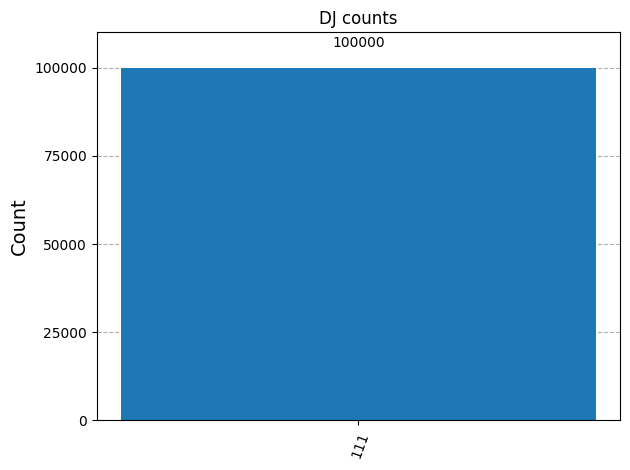

In [270]:
# Transpile
DJ_transpiled = transpile(DJ_circuit, simulator)

# Execution
results = simulator.run(DJ_transpiled, shots = 100000).result()
answer = results.get_counts()
plot_histogram(answer, title='DJ counts')

As we can see above, the result isn't 000, as expected, since the function f is balanced. The algorthm isn' affected by any randomness such as the QFT.

Now, let's make use of a quantum computer. First let's see what IBM computers we have available to perform our computations by connecting to the IBM QC by the API. 

In [155]:
service = QiskitRuntimeService(channel="ibm_quantum_platform", token="yweupdYmZAuxxcoeo8Q3H5ec1aZyvaI_zW8oYnrhnUrt")

qiskit_runtime_service._discover_account:WARNING:2026-02-08 20:18:44,871: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-02-08 20:18:50,288: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


In [156]:
service.backends(simulator=False, operational=True)

qiskit_runtime_service.backends:WARNING:2026-02-08 20:18:50,843: Loading instance: open-instance, plan: open


[<IBMBackend('ibm_fez')>,
 <IBMBackend('ibm_marrakesh')>,
 <IBMBackend('ibm_torino')>]

Let's make use of "ibm_fez"

In [157]:
backend_fez = service.backend('ibm_fez')

qiskit_runtime_service.backends:WARNING:2026-02-08 20:19:25,806: Using instance: open-instance, plan: open


This computer doesn't have the gates that we have to use in order to perform the circuit, therefore, we transpile it beforehand.

In [158]:
transpiled_QFT = transpile(QFT, backend=backend_fez)

In [179]:
sampler = Sampler(mode=backend_fez)
job_QFT = sampler.run([transpiled_QFT], shots = 100000)

In [184]:
job_QFT.status()

'DONE'

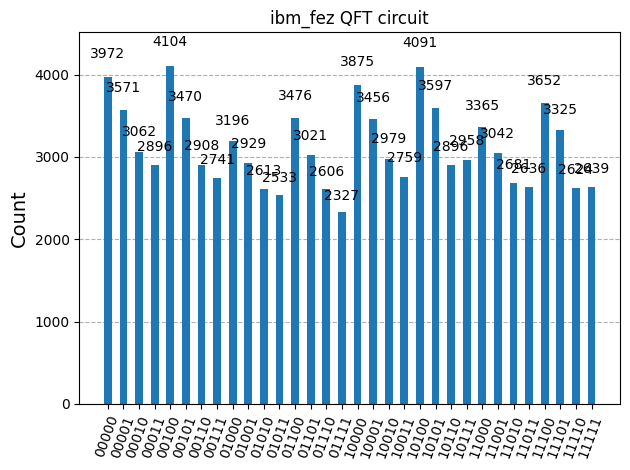

In [225]:
counts_DJ_qc = job_QFT.result()[0].data.meas.get_counts()
plot_histogram(counts_DJ_qc,title=f'{backend_fez.name} QFT circuit')

Making use of the argument to calculate the randomness of the simulator, we can calculate the noise of this circuit here.

In [236]:
sum_error_QFT = 0
for result in counts_DJ_qc:
    sum_error_QFT += abs(counts_DJ_qc[result]-100000/32)/2
print(sum_error_QFT/100000)

0.06525


As we can see the error rate of the circuit run in the ibm_fez backend could be calculated as 0.06525 - 0.00734 = 0.05791. This way could say we are considering only the noise, since the error due to randomness is of 0.00734, as we calculated in above cells.

Let's continue with the execution on the ibm_fez backend of the DJ circuit.

In [187]:
transpiled_DJ = transpile(DJ_circuit, backend = backend_fez)
job_DJ = sampler.run([transpiled_DJ], shots = 100000)

In [273]:
job_DJ.status()

'DONE'

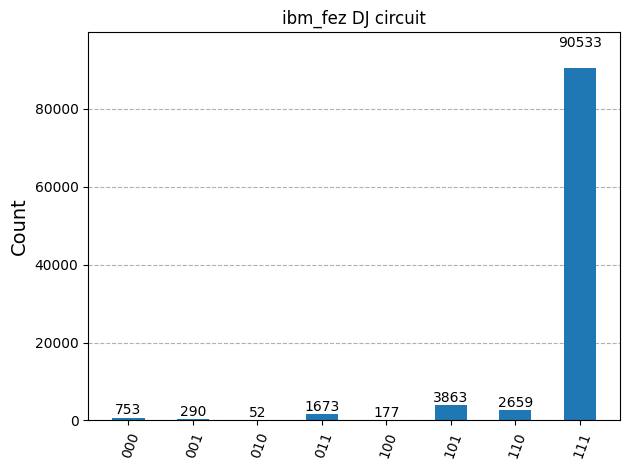

In [274]:
counts_DJ_qc = job_DJ.result()[0].data.c.get_counts()
plot_histogram(counts_DJ_qc,title=f'{backend_fez.name} DJ circuit')

In [275]:
sum_wrong_results_DJ = 0
for result in counts_DJ_qc:
    if result != "111":
        sum_wrong_results_DJ += counts_DJ_qc[result]
print(sum_wrong_results_DJ/100000)

0.09467


The algorithm detects that the function f is balanced with an accuracy = 1 - 753/100.000 = 0.99247, however, the result of the algorithm must be 111. Therefore, the circuit has an error rate of 0.09467 if we set the expected output 111 as the correct behaviour, while the circuit has en error rate of 753/100.000 = 0.000753 if we set that the algorithm has failed in detecting whether the function f is balanced. Therefore, in a pure functional matter, the DJ_circuit has performed better in the backend ibm_fez than the QFT_circuit, however, if we consider the exact outputs we should have gotten, the QFT clearly wins because the error rate in this specific case would be 0.05791 < 0.09467

# Excercise 4

In [214]:
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer.noise import NoiseModel
from qiskit_aer.noise.device.models import basic_device_gate_errors

Let's simulate the ibm_fez quantum computer. To do this, we need to pass the settings to our QASM simulator.

In [292]:
simulator = Aer.get_backend('qasm_simulator')
simulator.set_options(noise_model = NoiseModel.from_backend(backend_fez),
                      coupling_map = backend_fez.configuration().coupling_map,
                      basis_gates = NoiseModel.from_backend(backend_fez).basis_gates)

In [281]:
transpiled_DJ_noisy = transpile(DJ_circuit, backend = simulator)
counts_DJ_noisy = simulator.run(transpiled_DJ_noisy, shots= 100000).result().get_counts()

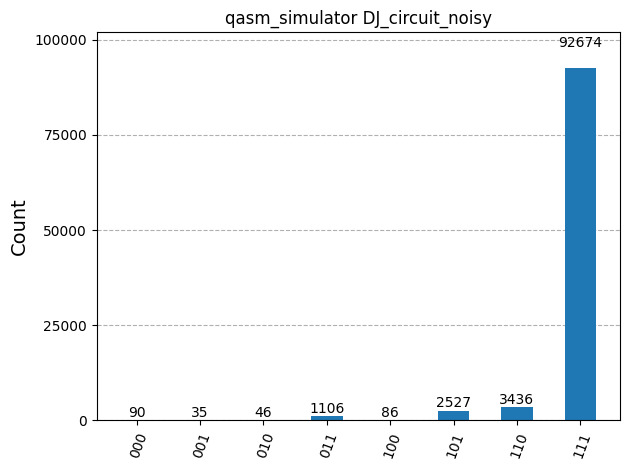

In [282]:
plot_histogram(counts_DJ_noisy,title=f'{simulator.name} DJ_circuit_noisy')

In [259]:
sum_error_DJ_noisy = 0
for result in counts_DJ_noisy:
    if result != "111":
        sum_error_DJ_noisy += counts_DJ_noisy[result]
print(sum_error_DJ_noisy/100000)

0.07231


The error rate of the simulator of the backend on the DJ circuit is a bit less than the quantum computer, but still noticeable 0.07231 < 0.09467

In [308]:
transpiled_QFT_noisy = transpile(QFT, backend = simulator)
counts_QFT_noisy = simulator.run(transpiled_QFT_noisy, shots= 100000).result().get_counts()

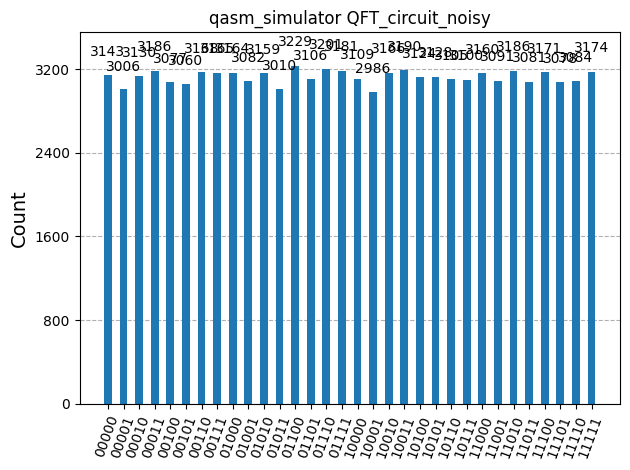

In [309]:
plot_histogram(counts_QFT_noisy,title=f'{simulator.name} QFT_circuit_noisy')

In [310]:
sum_error_QFT_noisy = 0
for result in counts_QFT_noisy:
    sum_error_QFT_noisy += abs(counts_QFT_noisy[result]-100000/32)/2
print(sum_error_QFT_noisy/100000)

0.00776


The error rate of the simulator of the backend on the QFT circuit is practically identical to the qasm simulator 0.00776 vs 0.00734 and is clearly far from the error produced by randomness an noise of the quantum computer 0.00776 vs 0.06525. Therefore, the noisy_simulator isn't grasping the error produced by the noise. On the other hand, the DJ circuit is clearly more affected by the noise with the noisy simulator, in fact, we can say that the noisy simulator does grasp does simulate the noise of the real quantum backend.